Enter number of points: 3
Enter point 1 (x y): 1 2
Enter point 2 (x y): 2 3
Enter point 3 (x y): 3 4

Enter Translation Values
Enter tx: 2
Enter ty: 5

Enter Rotation Value
Enter rotation angle in degrees: 45

Enter Scaling Values
Enter sx: 6
Enter sy: 1

Translation Matrix:
[[1. 0. 2.]
 [0. 1. 5.]
 [0. 0. 1.]]

Rotation Matrix:
[[ 0.70710678 -0.70710678  0.        ]
 [ 0.70710678  0.70710678  0.        ]
 [ 0.          0.          1.        ]]

Scaling Matrix:
[[6. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Composite Transformation Matrix:
[[ 4.2426 -0.7071  2.    ]
 [ 4.2426  0.7071  5.    ]
 [ 0.      0.      1.    ]]

Original Points:
[[1. 2.]
 [2. 3.]
 [3. 4.]]

Transformed Points:
[[ 4.83 10.66]
 [ 8.36 15.61]
 [11.9  20.56]]


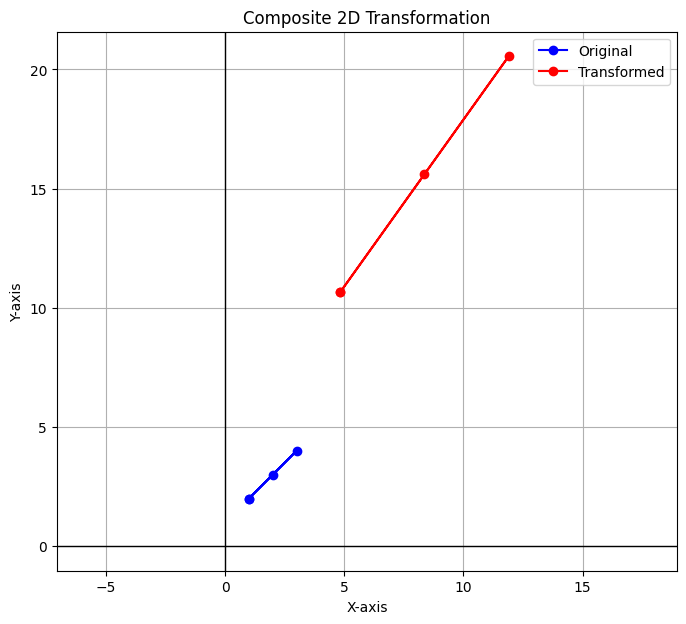

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Composite 2D Transformation using Homogeneous Coordinates
# Order: Scaling -> Rotation -> Translation
# --------------------------------------------------

# --------------------------------------------------
# Get points from user
# --------------------------------------------------

n = int(input("Enter number of points: "))

points = []

for i in range(n):
    x, y = map(float, input(f"Enter point {i+1} (x y): ").split())
    points.append([x, y, 1])

# Convert to homogeneous coordinate matrix
points = np.array(points).T


# --------------------------------------------------
# Transformation Functions
# --------------------------------------------------

def translation(tx, ty):
    return np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0, 1]
    ])


def rotation(angle):
    theta = np.radians(angle)

    return np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0, 0, 1]
    ])


def scaling(sx, sy):
    return np.array([
        [sx, 0, 0],
        [0, sy, 0],
        [0, 0, 1]
    ])


# --------------------------------------------------
# User Input
# --------------------------------------------------

print("\nEnter Translation Values")
tx = float(input("Enter tx: "))
ty = float(input("Enter ty: "))

print("\nEnter Rotation Value")
angle = float(input("Enter rotation angle in degrees: "))

print("\nEnter Scaling Values")
sx = float(input("Enter sx: "))
sy = float(input("Enter sy: "))


# --------------------------------------------------
# Create Transformation Matrices
# --------------------------------------------------

T = translation(tx, ty)
R = rotation(angle)
S = scaling(sx, sy)


# --------------------------------------------------
# Composite Transformation
# --------------------------------------------------
# First Scaling
# Then Rotation
# Then Translation
#
# P' = T × R × S × P
# --------------------------------------------------

C = T @ R @ S


# --------------------------------------------------
# Display Matrices
# --------------------------------------------------

print("\nTranslation Matrix:")
print(T)

print("\nRotation Matrix:")
print(R)

print("\nScaling Matrix:")
print(S)

print("\nComposite Transformation Matrix:")
print(np.round(C, 4))


# --------------------------------------------------
# Apply Composite Transformation
# --------------------------------------------------

transformed_points = C @ points


# --------------------------------------------------
# Display Points
# --------------------------------------------------

print("\nOriginal Points:")
print(np.round(points[:2].T, 2))

print("\nTransformed Points:")
print(np.round(transformed_points[:2].T, 2))


# --------------------------------------------------
# Close the polygon for plotting
# --------------------------------------------------

original = np.column_stack((
    points[:2],
    points[:2, 0]
))

transformed = np.column_stack((
    transformed_points[:2],
    transformed_points[:2, 0]
))


# --------------------------------------------------
# Plot
# --------------------------------------------------

plt.figure(figsize=(8, 7))

# Original object
plt.plot(
    original[0],
    original[1],
    'bo-',
    label="Original"
)

# Transformed object
plt.plot(
    transformed[0],
    transformed[1],
    'ro-',
    label="Transformed"
)

# Coordinate axes
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

plt.xlabel("X-axis")
plt.ylabel("Y-axis")

plt.title("Composite 2D Transformation")

plt.grid(True)
plt.legend()
plt.axis("equal")

plt.show()